##### Load library

In [1]:


import os
import re
import time
import asyncio
from typing import Dict, Any
from dotenv import load_dotenv

import pandas as pd
from sqlalchemy import create_engine, text
import psycopg
from langchain_community.utilities import SQLDatabase
from utility import execute_sql_safe
from utility import run_biochirp_query_hcdt
from utility import create_agent

load_dotenv()

True

In [2]:

MAX_ROWS = 100000
SAMPLE_ROWS = 3
RUNS = range(1, 2)
MAX_RETRIES = 3


##### Set database details

In [3]:

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("HCDT_DB_NAME")


In [4]:
DB_URI = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

db = SQLDatabase.from_uri(
    DB_URI,
    sample_rows_in_table_info=SAMPLE_ROWS
)

engine = create_engine(DB_URI)

In [5]:
schema = db.get_table_info()

In [6]:

conn = psycopg.connect(
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
)
print("Connected to DB")
conn.close()


Connected to DB


##### Table descriptions

In [7]:

TABLE_DESCRIPTIONS = {
    "drug_master_table": "Contains drug identifiers and drug names",
    "disease_master_table": "Contains disease identifiers and disease names",
    "gene_master_table": "Contains gene identifiers and gene symbols",
    "pathway_master_table": "Contains pathway identifiers and pathway names",
    "drug_disease_association": "Links drugs to diseases",
    "drug_gene_association": "Links drugs to genes",
    "drug_pathway_association": "Links drugs to pathways",
    "pathway_gene_association": "Links genes to pathways",
}

def format_table_descriptions(d: Dict[str, str]) -> str:
    return "\n".join(f"- {k}: {v}" for k, v in d.items())


##### Get schema

In [8]:
# Get schema once
db = SQLDatabase.from_uri(DB_URI, sample_rows_in_table_info=3)
schema = db.get_table_info()

##### Load question

In [9]:
QUESTION_LIST = [
    "What are the drugs used to treat CML?",
    "What are the drugs used to treat chronic myeloid leukemia?",
    "What are the drugs used to treat chronic myelogenous leukemia?",
    "What diseases are treated with Aspirin",
    "What diseases are treated with Vazalore?",
    "Which drugs target the EGFR?",
    "Which drug targets ERBB1?",
]

##### Load model

In [10]:
models = [
    ("groq", "llama-3.3-70b-versatile"),
    ("openai", "gpt-4.1-mini"),
    ("gemini", "gemini-2.5-flash-lite"),
    ("grok", "grok-4-1-fast-non-reasoning-latest"),
]


##### nl2SQL SYSTEM PROMPT

In [11]:
SYSTEM_PROMPT = f"""
═══════════════════════════════════════════════════════════════════════════════
ROLE: PostgreSQL Expert for Biomedical Knowledge Graph Querying
═══════════════════════════════════════════════════════════════════════════════

TASK:
Generate a single, syntactically correct PostgreSQL SELECT query that retrieves 
biomedical associations from the database to answer the user's question.

═══════════════════════════════════════════════════════════════════════════════
DATABASE SCHEMA
═══════════════════════════════════════════════════════════════════════════════

{schema}

TABLE SEMANTICS:
{TABLE_DESCRIPTIONS}

KEY RELATIONSHIPS:
- drug_gene_association: Links drugs (drug_id) to genes (gene_id)
- drug_disease_association: Links drugs (drug_id) to diseases (disease_id)
- gene_disease_association: Links genes (gene_id) to diseases (disease_id)
- pathway_gene_association: Links pathways (pathway_id) to genes (gene_id)

═══════════════════════════════════════════════════════════════════════════════
MANDATORY QUERY CONSTRUCTION RULES
═══════════════════════════════════════════════════════════════════════════════

1. SELECT CLAUSE:
   ✓ ALWAYS include *_name columns (drug_name, gene_name, disease_name, pathway_name)
   ✓ Use DISTINCT to eliminate duplicates
   ✗ NEVER include *_id columns in SELECT
   
   Example: SELECT DISTINCT dm.drug_name, gm.gene_name

2. FROM/JOIN CLAUSES:
   ✓ Use explicit INNER JOIN syntax
   ✓ Join tables using *_id foreign key columns
   ✓ Use table aliases (e.g., dm for drug_master_table, gm for gene_master_table)
   ✗ NEVER use implicit joins (comma-separated tables)
   ✗ NEVER use CROSS JOIN
   
   Example: 
   FROM drug_master_table dm
   INNER JOIN drug_gene_association dga ON dm.drug_id = dga.drug_id
   INNER JOIN gene_master_table gm ON dga.gene_id = gm.gene_id

3. WHERE CLAUSE:
   ✓ Filter on *_name columns using ILIKE for case-insensitive matching
   ✓ Use pattern: WHERE entity_name ILIKE '%search_term%'
   ✗ NEVER filter on *_id columns unless exact ID is provided
   
   Example: WHERE gm.gene_name ILIKE '%EGFR%'

4. ENTITY NAME VARIATIONS:
   • Handle abbreviations: "TB" = "Tuberculosis"
   • Handle synonyms: "TP53" = "P53"
   • Handle trade names: "IMATINIB"="Glamox"
   • Handle spelling variants
   • Use broad ILIKE patterns to capture variations

5. QUERY COMPLETENESS:
   ✓ Include ALL entity names referenced in the question
   ✓ Return both requested entities AND filtering entities
   
   Example: "What drugs target EGFR?" should SELECT both drug_name AND gene_name

═══════════════════════════════════════════════════════════════════════════════
QUERY PATTERNS BY QUESTION TYPE
═══════════════════════════════════════════════════════════════════════════════

PATTERN 1 - "What drugs treat disease X?"
SELECT DISTINCT dm.drug_name, dmt.disease_name
FROM drug_master_table dm
INNER JOIN drug_disease_association dda ON dm.drug_id = dda.drug_id
INNER JOIN disease_master_table dmt ON dda.disease_id = dmt.disease_id
WHERE dmt.disease_name ILIKE '%X%';

PATTERN 2 - "What drugs target gene Y?"
SELECT DISTINCT dm.drug_name, gm.gene_name
FROM drug_master_table dm
INNER JOIN drug_gene_association dga ON dm.drug_id = dga.drug_id
INNER JOIN gene_master_table gm ON dga.gene_id = gm.gene_id
WHERE gm.gene_name ILIKE '%Y%';

PATTERN 3 - "What diseases is drug Z used for?"
SELECT DISTINCT dmt.disease_name, dm.drug_name
FROM disease_master_table dmt
INNER JOIN drug_disease_association dda ON dmt.disease_id = dda.disease_id
INNER JOIN drug_master_table dm ON dda.drug_id = dm.drug_id
WHERE dm.drug_name ILIKE '%Z%';

PATTERN 4 - "What genes are associated with disease X?"
SELECT DISTINCT gm.gene_name, dmt.disease_name
FROM gene_master_table gm
INNER JOIN gene_disease_association gda ON gm.gene_id = gda.gene_id
INNER JOIN disease_master_table dmt ON gda.disease_id = dmt.disease_id
WHERE dmt.disease_name ILIKE '%X%';

═══════════════════════════════════════════════════════════════════════════════
VALIDATION CHECKLIST
═══════════════════════════════════════════════════════════════════════════════

Before returning, verify:
☐ Query starts with SELECT DISTINCT
☐ All *_name columns are in SELECT, no *_id columns
☐ All table names exist in the schema
☐ All column names exist in the schema
☐ JOINs use correct foreign key relationships
☐ WHERE clause uses ILIKE on *_name columns
☐ No syntax errors

═══════════════════════════════════════════════════════════════════════════════
OUTPUT FORMAT
═══════════════════════════════════════════════════════════════════════════════

Return ONLY the SQL query. Do NOT include:
- Explanations or commentary
- Markdown formatting (no ```sql blocks)
- Multiple query options
- Comments within the SQL

═══════════════════════════════════════════════════════════════════════════════
"""


In [12]:
#### Helper function
async def run_batch(framework: str = "langchain"):
    """
    Run batch queries.
    
    Args:
        framework: Which framework to use (langchain, phidata, pydanticai, crewai)
    """

    
    batch_results = {}

    batch_results[framework] = dict()
    
    for provider, model in models:
        print(f"\n--- Testing {framework}/{provider}/{model} ---")
        # model_key = f"{framework}_{provider}_{model.replace('-', '_')}"
        model_key = model

        # batch_results[model_key] = {}
        
        batch_results[framework][model_key] = dict()
        
        try:
            # CREATE AGENT (implementation depends on framework)
            agent = create_agent(provider, model, SYSTEM_PROMPT, framework=framework)
        except Exception as e:
            print(f"  Failed to create agent: {e}")
            continue
        
        for question in QUESTION_LIST:
            try:
                start = time.perf_counter()
                
                # Generate SQL (same interface for all frameworks!)
                sql_result = await agent.generate_sql(question)
                
                # Execute SQL (same for all frameworks!)
                exec_result = execute_sql_safe(sql_result["sql"], engine)
                
                total_latency = time.perf_counter() - start
                
                batch_results[framework][model_key][question] = {
                    "success": exec_result["success"],
                    "rows": exec_result["rows"],
                    "latency": total_latency,
                    "llm_latency": sql_result["latency"],
                    "sql": exec_result["sql"],
                    "dataframe": exec_result["dataframe"],
                    "error": exec_result["error"]
                }
                
                status = "✓" if exec_result["success"] else "✗"
                print(f"  {status} {question:50s} | {exec_result['rows']:4d} rows | {total_latency:.2f}s")
                
            except Exception as e:
                print(f"  ✗ {question:50s} | ERROR: {str(e)[:50]}")
                batch_results[model_key][question] = {
                    "success": False,
                    "error": str(e)
                }
    
    return batch_results


In [13]:
dct_results = dict()

# =============================================================================
# CrewAI
# =============================================================================

In [14]:
if __name__ == "__main__":
    print("\n" + "="*80)
    print("="*80)
    
    # results = await run_batch()
    print("Testing CrewAI...")
    results = await run_batch(framework="crewai")
    dct_results.update(results)
    
    print("\n" + "="*80)
    print("COMPLETED")
    print("="*80)
    



Testing CrewAI...

--- Testing crewai/groq/llama-3.3-70b-versatile ---
  ✓ What are the drugs used to treat CML?              |   12 rows | 0.75s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 0.80s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 0.85s
  ✓ What diseases are treated with Aspirin             |   52 rows | 0.75s
  ✓ What diseases are treated with Vazalore?           |    0 rows | 1.00s
  ✓ Which drugs target the EGFR?                       | 9824 rows | 0.70s
  ✓ Which drug targets ERBB1?                          |    0 rows | 0.61s

--- Testing crewai/openai/gpt-4.1-mini ---
  ✓ What are the drugs used to treat CML?              |    0 rows | 2.37s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 2.08s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 2.53s
  ✓ What diseases are treated with Aspirin             |   52 rows | 2.32s
  ✓ What diseases a

# =============================================================================
# Langchain
# =============================================================================

In [15]:


if __name__ == "__main__":
    print("\n" + "="*80)
    print("BIOMEDICAL NL2SQL - Langchain")
    print("="*80)
    
    # results = await run_batch()
    print("Testing LangChain...")
    results = await run_batch(framework="langchain")

    dct_results.update(results)
    
    print("\n" + "="*80)
    print("COMPLETED")
    print("="*80)
    



BIOMEDICAL NL2SQL - Langchain
Testing LangChain...

--- Testing langchain/groq/llama-3.3-70b-versatile ---
  ✓ What are the drugs used to treat CML?              |   12 rows | 0.69s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 0.49s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 0.54s
  ✓ What diseases are treated with Aspirin             |   52 rows | 0.72s
  ✓ What diseases are treated with Vazalore?           |    0 rows | 0.82s
  ✓ Which drugs target the EGFR?                       | 9824 rows | 0.84s
  ✓ Which drug targets ERBB1?                          |    0 rows | 0.64s

--- Testing langchain/openai/gpt-4.1-mini ---
  ✓ What are the drugs used to treat CML?              |    0 rows | 2.77s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 2.59s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 2.57s
  ✓ What diseases are treated with Aspirin             

# =============================================================================
# Phidata
# =============================================================================

In [16]:


if __name__ == "__main__":
    print("\n" + "="*80)
    print("="*80)
    
    # results = await run_batch()
    print("Testing Phidata...")
    results = await run_batch(framework="phidata")
    dct_results.update(results)
    
    print("\n" + "="*80)
    print("COMPLETED")
    print("="*80)



Testing Phidata...

--- Testing phidata/groq/llama-3.3-70b-versatile ---
  ✓ What are the drugs used to treat CML?              |   12 rows | 2.00s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 1.85s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 1.90s
  ✓ What diseases are treated with Aspirin             |   52 rows | 1.91s
  ✓ What diseases are treated with Vazalore?           |    0 rows | 2.06s
  ✓ Which drugs target the EGFR?                       | 9824 rows | 1.88s
  ✓ Which drug targets ERBB1?                          |    0 rows | 1.74s

--- Testing phidata/openai/gpt-4.1-mini ---
  ✓ What are the drugs used to treat CML?              |    0 rows | 3.06s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 3.58s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 3.26s
  ✓ What diseases are treated with Aspirin             |   52 rows | 3.40s
  ✓ What disease

/home/abhishekh/anaconda3/envs/biochirp/lib/python3.11/site-packages/phi/model/google/gemini.py:19: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


  ✓ What are the drugs used to treat CML?              |    0 rows | 2.49s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 2.28s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 2.47s
  ✓ What diseases are treated with Aspirin             |   52 rows | 2.76s
  ✓ What diseases are treated with Vazalore?           |    0 rows | 3.42s
  ✓ Which drugs target the EGFR?                       | 9824 rows | 2.51s
  ✓ Which drug targets ERBB1?                          |    0 rows | 2.10s

--- Testing phidata/grok/grok-4-1-fast-non-reasoning-latest ---
  ✓ What are the drugs used to treat CML?              |    0 rows | 2.36s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 2.16s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 2.26s
  ✓ What diseases are treated with Aspirin             |   52 rows | 2.57s
  ✓ What diseases are treated with Vazalore?           |    0 rows | 2

# =============================================================================
# PydanticAI
# =============================================================================

In [17]:


if __name__ == "__main__":
    print("\n" + "="*80)
    print("="*80)
    
    # results = await run_batch()
    print("Testing pydanticai...")
    results = await run_batch(framework="pydanticai")
    dct_results.update(results)
    
    print("\n" + "="*80)
    print("COMPLETED")
    print("="*80)



Testing pydanticai...

--- Testing pydanticai/groq/llama-3.3-70b-versatile ---
  ✓ What are the drugs used to treat CML?              |   12 rows | 0.53s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 0.39s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 0.38s
  ✓ What diseases are treated with Aspirin             |   52 rows | 0.61s
  ✓ What diseases are treated with Vazalore?           |    0 rows | 0.72s
  ✓ Which drugs target the EGFR?                       | 9824 rows | 0.59s
  ✓ Which drug targets ERBB1?                          |    0 rows | 0.43s

--- Testing pydanticai/openai/gpt-4.1-mini ---
  ✓ What are the drugs used to treat CML?              |    0 rows | 1.87s
  ✓ What are the drugs used to treat chronic myeloid leukemia? |   12 rows | 1.43s
  ✓ What are the drugs used to treat chronic myelogenous leukemia? |    0 rows | 1.62s
  ✓ What diseases are treated with Aspirin             |   52 rows | 1.89s
  ✓ Wha

##### BioChirp

In [18]:


biochirp_results = {}
framework = "BioChirp"

biochirp_results[framework] = dict()
biochirp_results[framework]["HCDT_retriver"] = dict()


# batch_results[model_key] = {}
for question in QUESTION_LIST:
    try:
        start = time.perf_counter()

        df = await run_biochirp_query_hcdt(question)
    
        total_latency = time.perf_counter() - start
        
        biochirp_results[framework]["HCDT_retriver"][question] = {
            # "success": exec_result["success"],
            "rows": df.shape[0],
            "latency": total_latency,
            # "llm_latency": total_latency,
            # "sql": exec_result["sql"],
            "dataframe": df,
            # "error": exec_result["error"]
        }
        
        # status = "✓" if exec_result["success"] else "✗"
        # print(f"  {status} {question:50s} | {exec_result['rows']:4d} rows | {total_latency:.2f}s")
        
    except Exception as e:
        print(f"  ✗ {question:50s} | ERROR: {str(e)[:50]}")
        biochirp_results[question] = {
            "success": False,
            "error": str(e)
        }

# return batch_results
dct_results.update(biochirp_results)

Connected to orchestrator | connection_id=ws-8-1774187863-4d4570fe
HCDT CSV announced | rows=24
Orchestrator finished
Connected to orchestrator | connection_id=ws-9-1774187911-a8149a31
HCDT CSV announced | rows=24
Orchestrator finished
Connected to orchestrator | connection_id=ws-8-1774187957-92a63d57
HCDT CSV announced | rows=24
Orchestrator finished
Connected to orchestrator | connection_id=ws-8-1774188008-d5c4b4fe
HCDT CSV announced | rows=48
Orchestrator finished
Connected to orchestrator | connection_id=ws-8-1774188079-027f9bc4
HCDT CSV announced | rows=48
Orchestrator finished
Connected to orchestrator | connection_id=ws-8-1774188128-c77ab4ce
HCDT CSV announced | rows=9824
Orchestrator finished
Connected to orchestrator | connection_id=ws-8-1774188184-619c22da
HCDT CSV announced | rows=9824
Orchestrator finished


##### Store the result as dataframe

In [19]:
records = []
for framework, models_dict in dct_results.items():
    for model_name, questions_dict in models_dict.items():
        for question, result_data in questions_dict.items():
            records.append({
                "Framework": framework,
                "Model": model_name,
                "Question": question,
                "Rows": result_data.get("rows", 0) if isinstance(result_data, dict) else 0,
                "latency" : result_data.get("latency", 0)
            })

df = pd.DataFrame(records)


In [20]:
df.to_excel("nl2SQL_result.xlsx", index=False)

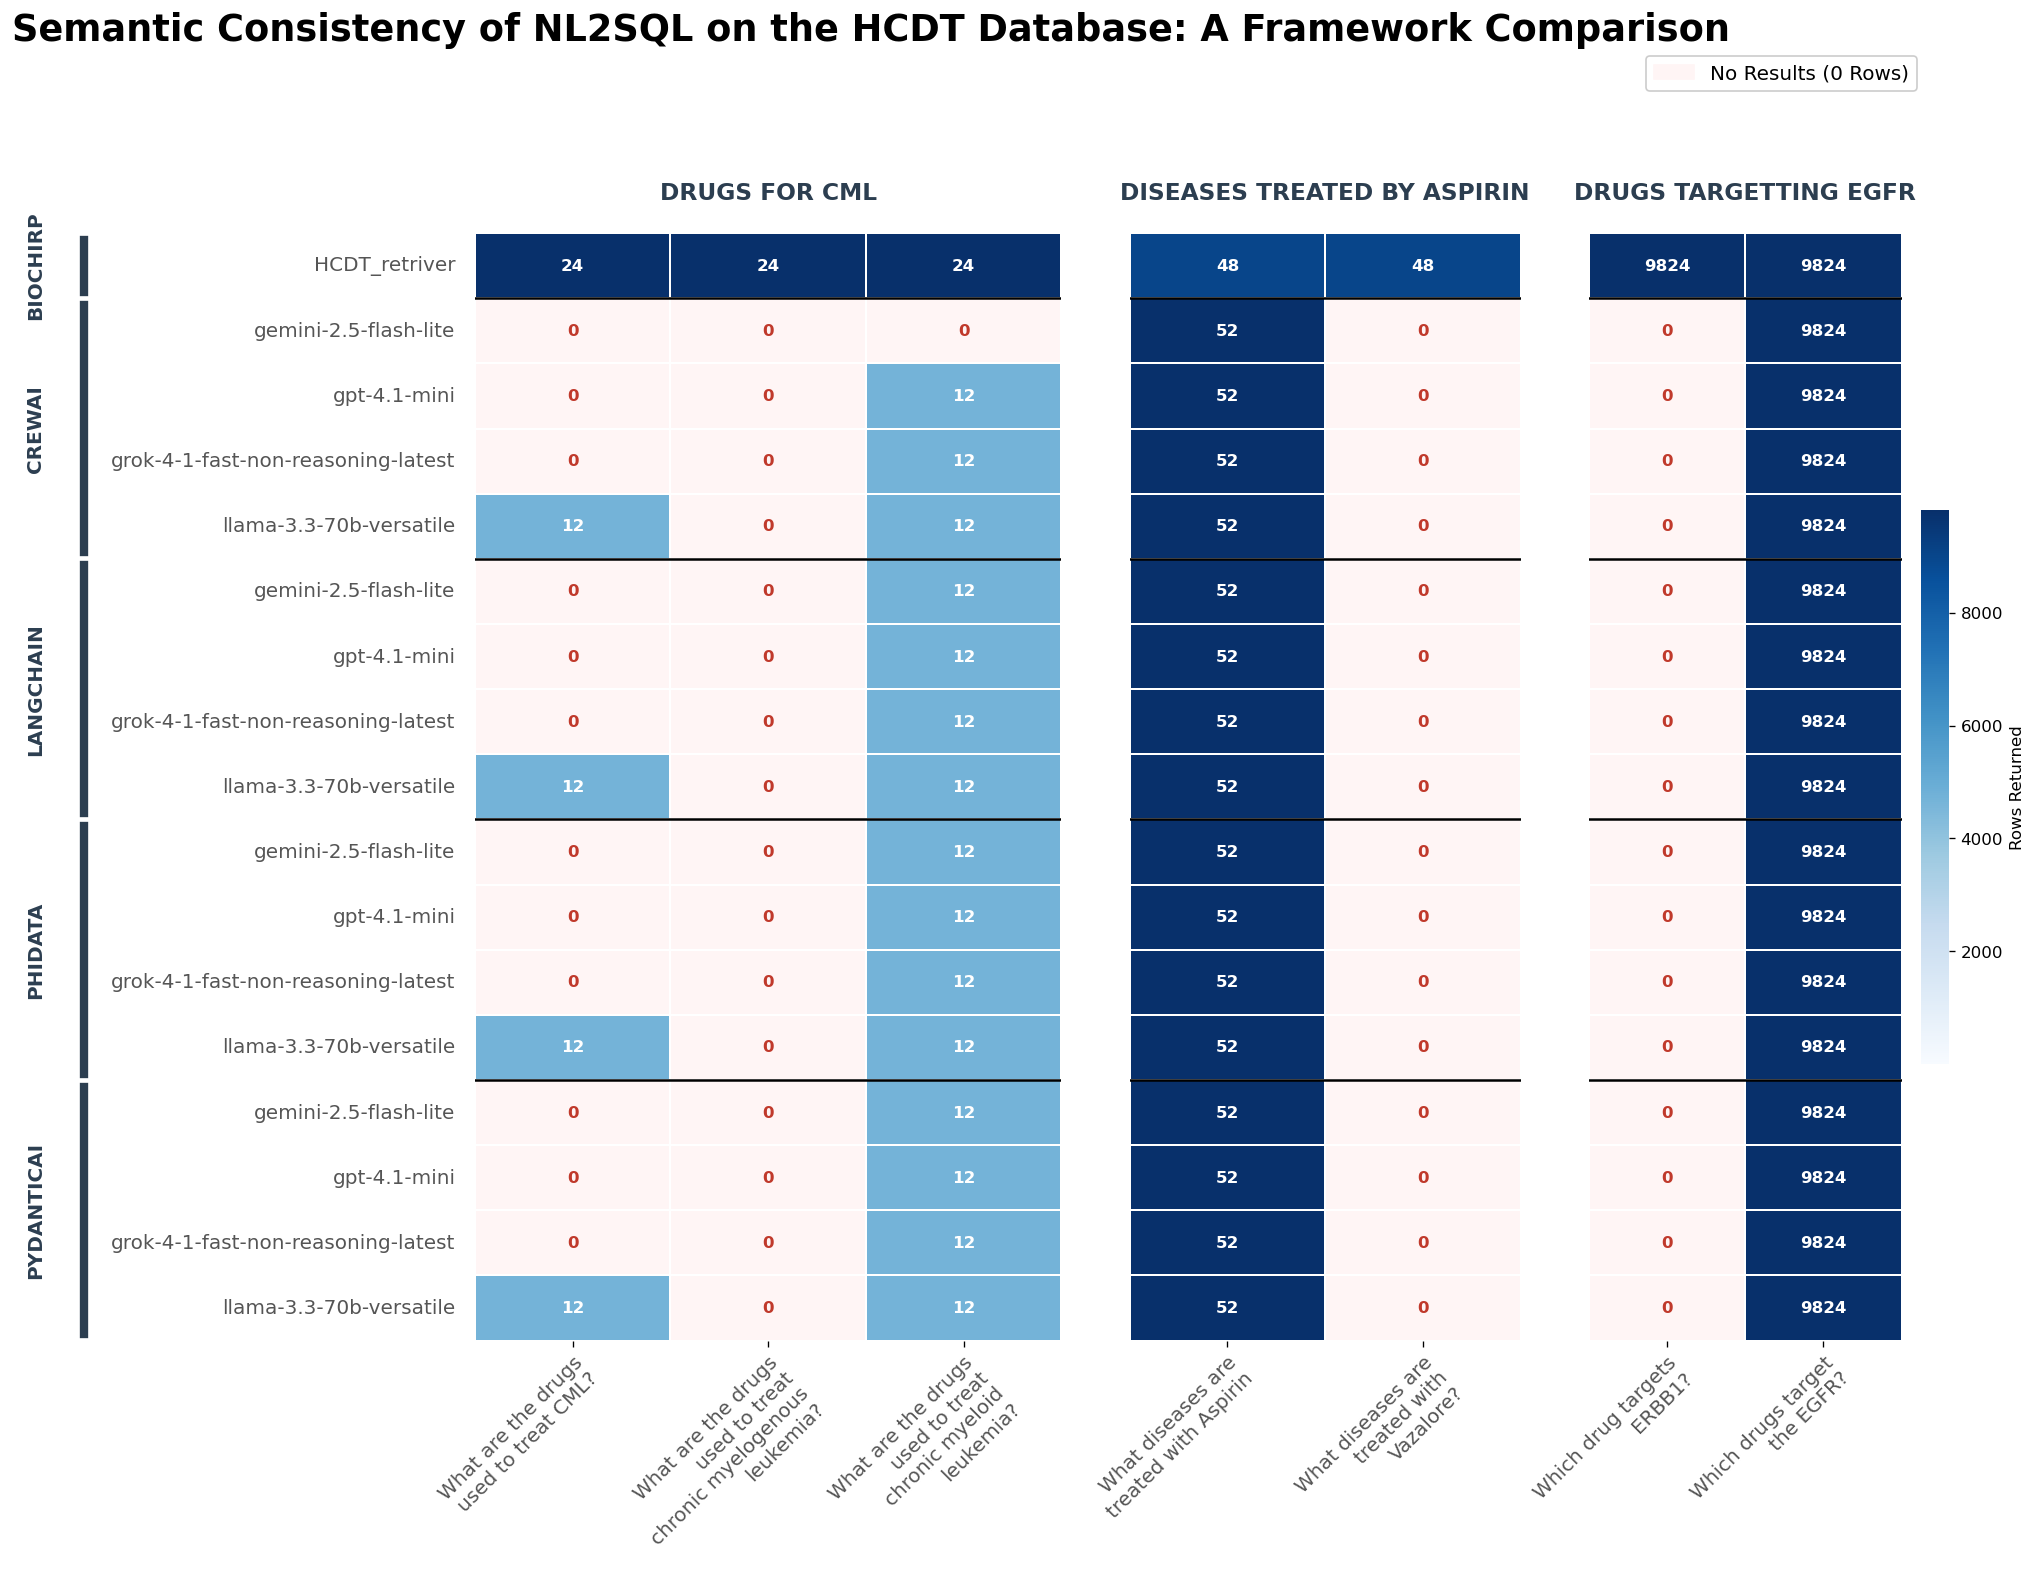

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import textwrap
import numpy as np

# --- 1. PREPARE DATA ---
# (Assuming 'dct_results' is your input dictionary)
records = []
for framework, models_dict in dct_results.items():
    for model_name, questions_dict in models_dict.items():
        for question, result_data in questions_dict.items():
            records.append({
                "Framework": framework,
                "Model": model_name,
                "Question": question,
                "Rows": result_data.get("rows", 0) if isinstance(result_data, dict) else 0,
                "latency" : result_data.get("latency", 0)
            })

df = pd.DataFrame(records)

# Define Semantic Groups
groups = {
    "DRUGS FOR CML": ["CML", "myeloid", "myelogenous"],
    "DISEASES TREATED BY ASPIRIN": [  "Vazalore", "Aspirin"],
    "DRUGS TARGETTING EGFR": ["ERBB1", "EGFR" ]
}

# Create a combined index to ensure the heatmap rows align perfectly
df["SortKey"] = df["Framework"] + "_" + df["Model"]
df = df.sort_values(["Framework", "Model"])
unique_y_labels = df[["Framework", "Model"]].drop_duplicates().reset_index(drop=True)

# --- 2. SETUP PLOT LAYOUT ---
# Dynamic Height calculation
row_height = 0.6
n_rows = len(unique_y_labels)
fig_height = max(6, n_rows * row_height + 4) 

fig = plt.figure(figsize=(22, fig_height), dpi=120)

# Calculate column width ratios based on number of questions per group
col_counts = [len([q for q in df["Question"].unique() if any(k.lower() in q.lower() for k in keys)]) for keys in groups.values()]
gs = gridspec.GridSpec(1, 3, width_ratios=col_counts, wspace=0.15)

axes = []
for i in range(3):
    axes.append(fig.add_subplot(gs[i]))

# Colors
cmap_failure = sns.color_palette(["#fff5f5"]) # Light Red for zeros
# Use a distinct red for the legend
failure_patch = mpatches.Patch(color='#fff5f5', label='No Results (0 Rows)')

# --- 3. PLOT EACH GROUP ---
for ax_idx, (group_name, keywords) in enumerate(groups.items()):
    ax = axes[ax_idx]
    
    # Filter Data
    group_questions = [q for q in df["Question"].unique() if any(k.lower() in q.lower() for k in keywords)]
    
    # Pivot
    group_df = df[df["Question"].isin(group_questions)].pivot_table(
        index=["Framework", "Model"], 
        columns="Question", 
        values="Rows", 
        fill_value=0
    )
    # Reindex to ensure alignment with the master list
    group_df = group_df.reindex(pd.MultiIndex.from_frame(unique_y_labels), fill_value=0)
    
    # A. Plot Background (Zeros/Failures)
    mask_zeros = group_df == 0
    sns.heatmap(
        group_df, mask=~mask_zeros, 
        cmap=cmap_failure, 
        cbar=False, annot=True, fmt=".0f", 
        annot_kws={"color": "#c0392b", "weight": "bold"}, # Red text for 0
        linewidths=1, linecolor='white', ax=ax
    )
    
    # B. Plot Foreground (Values)
    show_cbar = (ax_idx == 2)
    sns.heatmap(
        group_df, mask=mask_zeros, 
        cmap="Blues", 
        cbar=show_cbar, 
        cbar_kws={"label": "Rows Returned", "shrink": 0.5} if show_cbar else None,
        annot=True, fmt=".0f", 
        annot_kws={"color": "white", "weight": "bold"}, # White text for values
        linewidths=1, linecolor='white', vmin=1, ax=ax
    )
    
    # C. Formatting
    ax.set_title(group_name, fontsize=14, fontweight="bold", pad=20, color="#2c3e50")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([]) 
    
    wrapped_labels = [textwrap.fill(q, width=20) for q in group_df.columns]
    ax.set_xticklabels(wrapped_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=12, color="#555")
    # ax.set_xticklabels(rotation=45, ha="right", rotation_mode="anchor", fontsize=12, color="#555")

# --- 4. DRAW CUSTOM Y-AXIS (Left Side) ---
first_ax = axes[0]
y_min, y_max = first_ax.get_ylim()

fw_counts = unique_y_labels["Framework"].value_counts(sort=False)
current_y = 0
frameworks_ordered = unique_y_labels["Framework"].unique()

for fw in frameworks_ordered:
    count = fw_counts[fw]
    center_y = current_y + (count / 2)
    
    # --- FIX: MOVE BAR LEFT ---
    # Position the bar at x = -2.5 (data coords) to clear long model names
    bar_x_pos = -2.0
    
    # 1. Framework Line (Thick Vertical Bar)
    first_ax.plot([bar_x_pos, bar_x_pos], [current_y + 0.1, current_y + count - 0.1], 
                  color="#2c3e50", linewidth=5, clip_on=False)
    
    # 2. Framework Label (Rotated)
    # Position text slightly left of the bar
    first_ax.text(bar_x_pos - 0.2, center_y, fw.upper(), 
                  ha="right", va="center", rotation=90, 
                  fontweight="bold", fontsize=12, color="#2c3e50")
    
    # 3. Model Labels (Keep close to heatmap)
    models = unique_y_labels[unique_y_labels["Framework"] == fw]["Model"].tolist()
    for i, model in enumerate(models):
        clean_model = model.replace("groq_", "").replace("openai_", "").replace("google_", "").replace("anthropic_", "")
        first_ax.text(-0.1, current_y + i + 0.5, clean_model, 
                      ha="right", va="center", fontsize=12, color="#555", weight="medium")
    
    # 4. Horizontal Divider
    if current_y + count < n_rows:
        for ax in axes:
            ax.axhline(current_y + count, color="black", linewidth=1.5)
            
    current_y += count

# --- 5. ADD CUSTOM LEGEND ---
fig.legend(handles=[failure_patch], loc='upper right', bbox_to_anchor=(0.9, 0.96), 
           fontsize=12, frameon=True, facecolor='white', framealpha=1)

# --- 6. FINAL LAYOUT ADJUSTMENTS ---
fig.suptitle("Semantic Consistency of NL2SQL on the HCDT Database: A Framework Comparison", fontsize=22, weight='bold', y=0.98)

# --- FIX: INCREASE LEFT MARGIN ---
# Increase left to 0.35 to prevent the new "far left" labels from being cut off
plt.subplots_adjust(left=0.35, bottom=0.2, right=0.92, top=0.85)

plt.show()

In [22]:
# dct_results['crewai']['llama-3.3-70b-versatile']['What diseases are treated with Aspirin']['dataframe']
